# Model Evaluation — Large Language Models & Transformer Tasks

Notebook ini mencakup metrik evaluasi lengkap untuk berbagai **Transformer task**:

| Task | Model HuggingFace | Metrik Utama |
|------|------------------|---------------|
| Sequence Classification | `AutoModelForSequenceClassification` | Accuracy, F1, ROC-AUC |
| Token Classification (NER) | `AutoModelForTokenClassification` | Entity F1 (seqeval) |
| Causal LM / Text Generation | `AutoModelForCausalLM` | Perplexity, Loss |
| Machine Translation | `AutoModelForSeq2SeqLM` | BLEU, chrF |
| Summarization | `AutoModelForSeq2SeqLM` | ROUGE-1/2/L |
| Question Answering | `AutoModelForQuestionAnswering` | Exact Match, F1 |

> Semua data prediksi dan aktual menggunakan **data dummy** yang di-generate dengan NumPy — dapat langsung dijalankan tanpa GPU atau API key.

### 1. Import Library & Setup
Seluruh metrik evaluasi diimpor dari `sklearn`, `nltk`, dan `rouge_score`. Visualisasi menggunakan `matplotlib` dan `seaborn` dengan tema yang konsisten.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Classification metrics
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef
)
from sklearn.preprocessing import label_binarize

# Text generation metrics
try:
    from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    import nltk
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    NLTK_OK = True
except ImportError:
    NLTK_OK = False

try:
    from rouge_score import rouge_scorer
    ROUGE_OK = True
except ImportError:
    ROUGE_OK = False
    print("rouge_score tidak ada — install: pip install rouge-score")

np.random.seed(42)

# === Tema visual konsisten ===
PALETTE   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

print("Library siap.")
print(f"  NLTK      : {'✓' if NLTK_OK else '✗'}")
print(f"  rouge_score: {'✓' if ROUGE_OK else '✗'}")

rouge_score tidak ada — install: pip install rouge-score
Library siap.
  NLTK      : ✓
  rouge_score: ✗


---
## TASK 1: Sequence Classification (Sentiment Analysis)
### 2. Data Dummy — Klasifikasi 3 Kelas
Simulasi output `AutoModelForSequenceClassification` untuk tugas analisis sentimen: **Negative (0)**, **Neutral (1)**, **Positive (2)**. Data mencerminkan model yang cukup baik dengan beberapa kesalahan klasifikasi antar kelas yang berdekatan.

In [2]:
# === Generate dummy data: 3-class sentiment ===
N_SAMPLES   = 300
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']
N_CLASSES   = len(CLASS_NAMES)

# Ground truth: distribusi tidak merata (lebih banyak positive)
y_true = np.array(
    [0]*80 + [1]*90 + [2]*130
)
np.random.shuffle(y_true)

# Simulasi prediksi: beberapa kesalahan antar kelas berdekatan
y_pred = y_true.copy()
noise_idx = np.random.choice(N_SAMPLES, size=55, replace=False)
# Kebanyakan salah ke kelas sebelah (0↔1, 1↔2)
for i in noise_idx:
    if y_pred[i] == 0:
        y_pred[i] = 1
    elif y_pred[i] == 2:
        y_pred[i] = np.random.choice([1, 2])
    else:
        y_pred[i] = np.random.choice([0, 2])

# Simulasi probabilitas (softmax output dari model)
def make_proba(y_true, noise=0.25):
    n = len(y_true)
    proba = np.zeros((n, N_CLASSES))
    for i, label in enumerate(y_true):
        base = np.random.dirichlet([0.5, 0.5, 0.5])
        confidence = np.random.uniform(0.55, 0.95)
        proba[i] = base * (1 - confidence)
        proba[i, label] += confidence
        proba[i] /= proba[i].sum()
    return proba

y_prob = make_proba(y_true)

print(f"Sampel: {N_SAMPLES}")
print(f"Distribusi y_true: {dict(zip(CLASS_NAMES, np.bincount(y_true)))}")
print(f"Distribusi y_pred: {dict(zip(CLASS_NAMES, np.bincount(y_pred)))}")
print(f"Contoh y_prob[0]: {y_prob[0].round(3)} (label={y_true[0]})")

Sampel: 300
Distribusi y_true: {'Negative': np.int64(80), 'Neutral': np.int64(90), 'Positive': np.int64(130)}
Distribusi y_pred: {'Negative': np.int64(69), 'Neutral': np.int64(103), 'Positive': np.int64(128)}
Contoh y_prob[0]: [0.026 0.001 0.973] (label=2)


### 3. Confusion Matrix & Classification Report
**Confusion matrix** menunjukkan secara visual berapa sampel yang diprediksi benar/salah untuk setiap kombinasi kelas. **Classification report** merangkum precision, recall, dan F1-score per kelas serta rata-ratanya (macro, weighted).

  CLASSIFICATION METRICS SUMMARY
  Accuracy         : 0.8433
  F1 (Macro)       : 0.8345  ← untuk imbalanced
  F1 (Weighted)    : 0.8452
  Precision (Macro): 0.8431
  Recall (Macro)   : 0.8313
  MCC              : 0.7612  ← Matthews Correlation Coef

              precision    recall  f1-score   support

    Negative       0.90      0.78      0.83        80
     Neutral       0.71      0.81      0.76        90
    Positive       0.92      0.91      0.91       130

    accuracy                           0.84       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.85      0.84      0.85       300



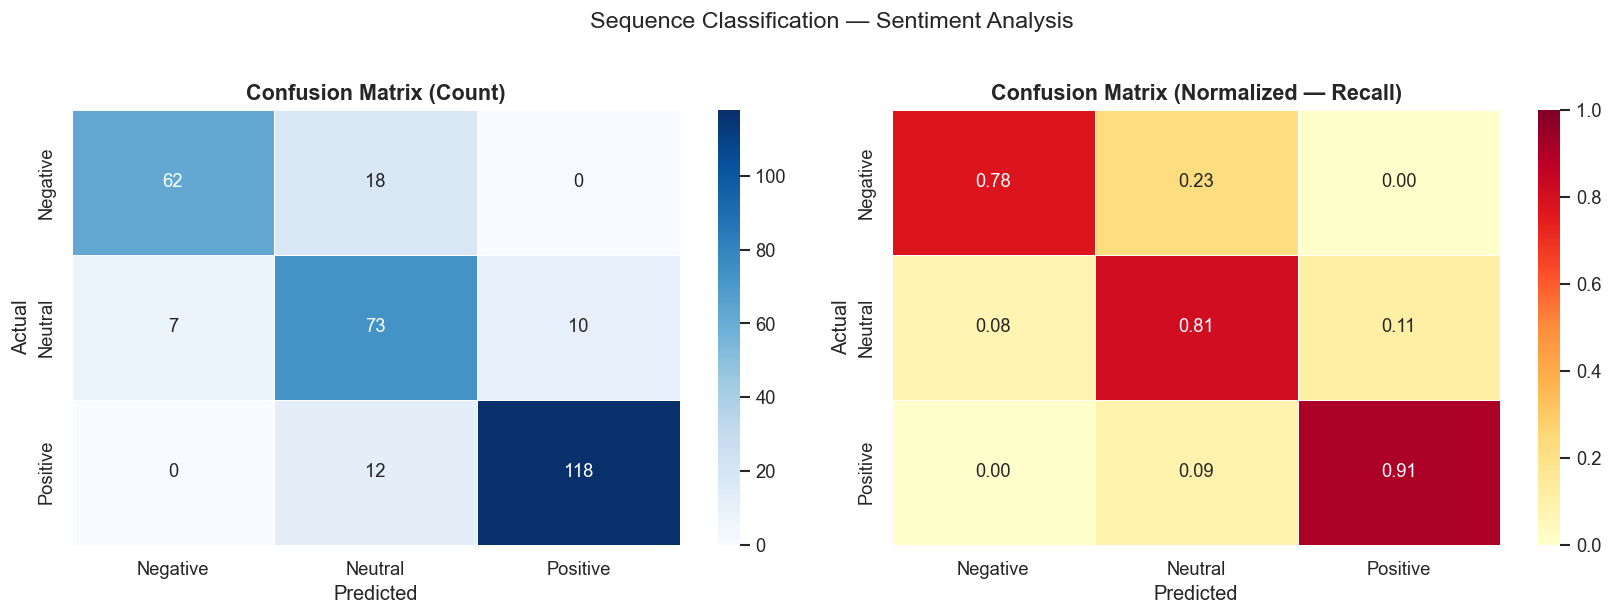

In [3]:
# === Metrik Klasifikasi ===
acc      = accuracy_score(y_true, y_pred)
f1_mac   = f1_score(y_true, y_pred, average='macro')
f1_wei   = f1_score(y_true, y_pred, average='weighted')
prec_mac = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_mac  = recall_score(y_true, y_pred, average='macro', zero_division=0)
mcc      = matthews_corrcoef(y_true, y_pred)

print("=" * 50)
print("  CLASSIFICATION METRICS SUMMARY")
print("=" * 50)
print(f"  Accuracy         : {acc:.4f}")
print(f"  F1 (Macro)       : {f1_mac:.4f}  ← untuk imbalanced")
print(f"  F1 (Weighted)    : {f1_wei:.4f}")
print(f"  Precision (Macro): {prec_mac:.4f}")
print(f"  Recall (Macro)   : {rec_mac:.4f}")
print(f"  MCC              : {mcc:.4f}  ← Matthews Correlation Coef")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# === Visualisasi: Confusion Matrix (angka + normalisasi) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Count)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized (row-wise: recall per kelas)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized — Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Sequence Classification — Sentiment Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4. ROC-AUC Curve (Multi-class, OvR)
Untuk klasifikasi multi-kelas, **ROC-AUC** dihitung dengan strategi **One-vs-Rest (OvR)**: setiap kelas diperlakukan sebagai kelas positif, sisanya sebagai negatif. Area Under Curve (AUC) yang tinggi menunjukkan model mampu membedakan kelas dengan baik.

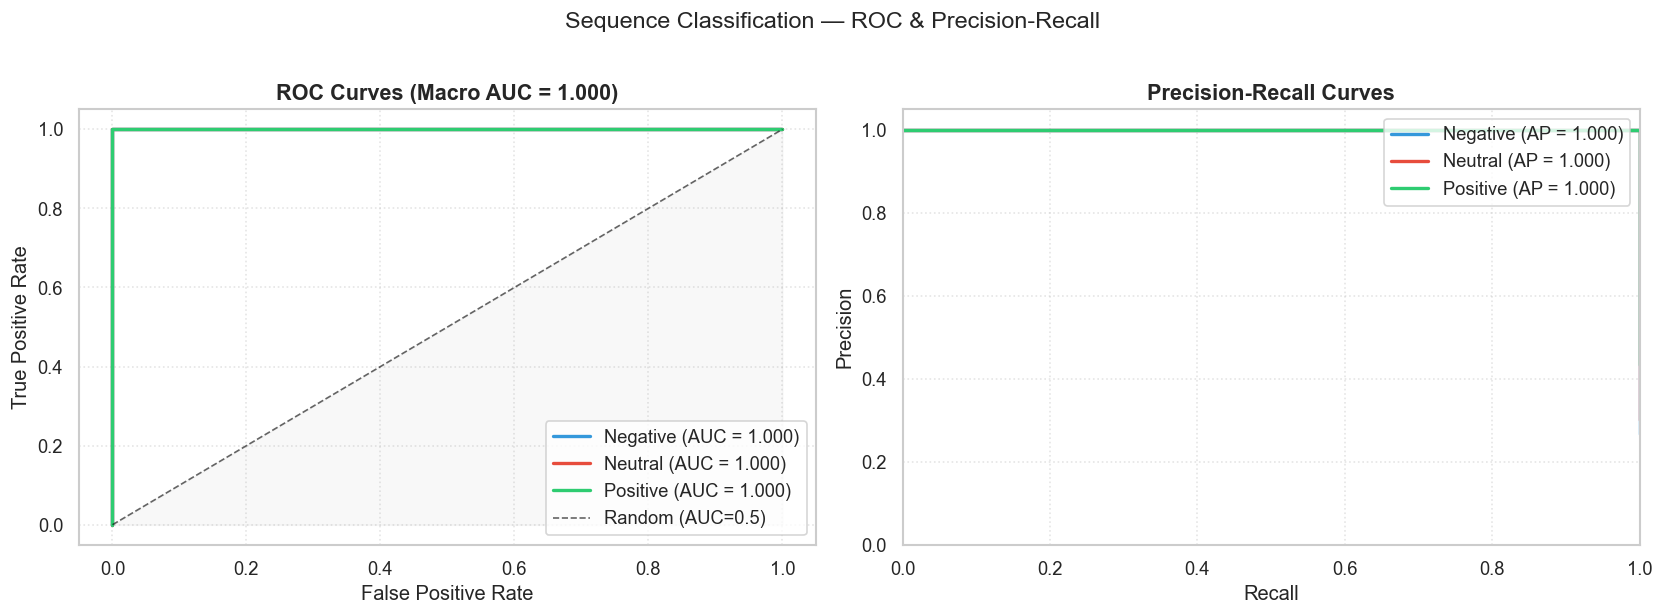

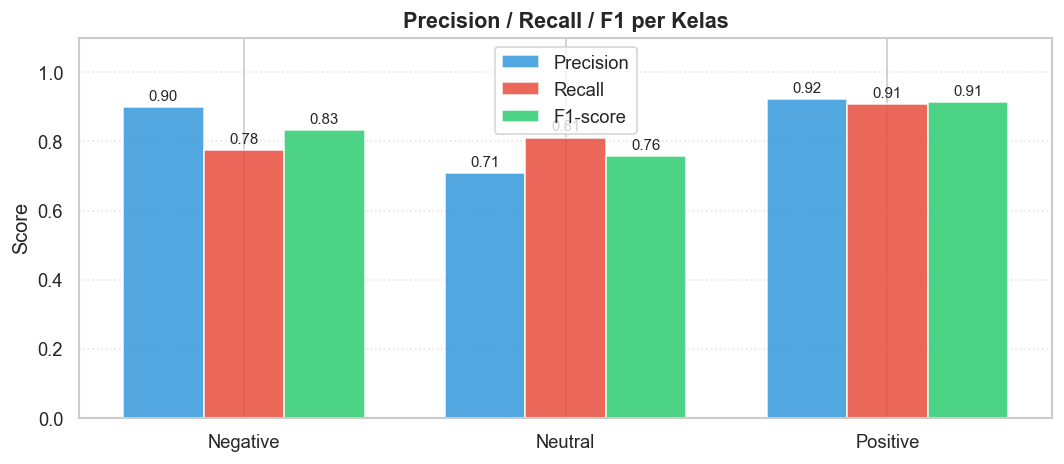

In [4]:
# Binarize untuk OvR
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
roc_auc_macro = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve per kelas ---
ax = axes[0]
for i, (cls, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random (AUC=0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title(f'ROC Curves (Macro AUC = {roc_auc_macro:.3f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(linestyle=':', alpha=0.5)

# --- Precision-Recall Curve ---
ax = axes[1]
for i, (cls, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    prec_c, rec_c, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    ax.plot(rec_c, prec_c, color=color, lw=2,
            label=f'{cls} (AP = {ap:.3f})')

ax.set_title('Precision-Recall Curves')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right')
ax.grid(linestyle=':', alpha=0.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.suptitle('Sequence Classification — ROC & Precision-Recall', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Bar chart metrik per kelas
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
metrics_df = pd.DataFrame(report).T.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(N_CLASSES)
width = 0.25
for i, (col, color) in enumerate(zip(['precision', 'recall', 'f1-score'], PALETTE)):
    bars = ax.bar(x + i * width, metrics_df[col], width, label=col.capitalize(),
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.set_title('Precision / Recall / F1 per Kelas')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

---
## TASK 2: Token Classification (NER)
### 5. Data Dummy — Named Entity Recognition
`AutoModelForTokenClassification` digunakan untuk NER — setiap token mendapat label entitas menggunakan format **BIO**: `B-` (Beginning), `I-` (Inside), `O` (Outside/non-entity). Evaluasi NER dilakukan di level **entitas** (bukan token), menggunakan library `seqeval`.

In [5]:
# === Data BIO dummy untuk NER ===
ner_true = [
    ['O', 'B-PER', 'I-PER', 'O', 'B-ORG', 'I-ORG', 'O', 'B-LOC', 'O'],
    ['B-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O'],
    ['O', 'O', 'B-LOC', 'I-LOC', 'O', 'B-PER', 'I-PER', 'I-PER', 'O', 'O'],
    ['B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'B-LOC', 'O'],
    ['O', 'B-PER', 'O', 'O', 'B-DATE', 'I-DATE', 'O'],
    ['B-LOC', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'B-PER', 'O'],
    ['O', 'O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O'],
    ['B-DATE', 'I-DATE', 'O', 'B-ORG', 'O', 'B-PER', 'O', 'O'],
]

# Simulasi prediksi: beberapa error umum NER
ner_pred = [
    ['O', 'B-PER', 'I-PER', 'O', 'B-ORG', 'O',     'O', 'B-LOC', 'O'],   # I-ORG missed
    ['B-PER', 'O', 'O', 'B-ORG', 'O', 'O', 'O'],
    ['O', 'O', 'B-LOC', 'I-LOC', 'O', 'B-PER', 'I-PER', 'O', 'O', 'O'],   # last I-PER missed
    ['B-ORG', 'I-ORG', 'I-ORG', 'O', 'O', 'B-PER', 'O'],                   # LOC → PER
    ['O', 'B-PER', 'O', 'O', 'B-DATE', 'I-DATE', 'O'],
    ['B-ORG', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'B-PER', 'O'],              # LOC → ORG
    ['O', 'O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O'],
    ['B-DATE', 'I-DATE', 'O', 'B-ORG', 'O', 'O', 'O', 'O'],                # PER missed
]

# Evaluasi seqeval (manual jika seqeval tidak terinstall)
try:
    from seqeval.metrics import classification_report as seq_report
    from seqeval.metrics import f1_score as seq_f1, precision_score as seq_prec, recall_score as seq_rec
    SEQEVAL_OK = True
except ImportError:
    SEQEVAL_OK = False

# Manual entity extraction untuk visualisasi
def extract_entities(sequences):
    """Extract (entity_type, start, end) spans from BIO sequences."""
    all_entities = []
    for seq in sequences:
        entities = []
        current_entity, start = None, None
        for i, tag in enumerate(seq):
            if tag.startswith('B-'):
                if current_entity:
                    entities.append((current_entity, start, i))
                current_entity, start = tag[2:], i
            elif tag.startswith('I-') and current_entity:
                pass  # continue current entity
            else:
                if current_entity:
                    entities.append((current_entity, start, i))
                current_entity, start = None, None
        if current_entity:
            entities.append((current_entity, start, len(seq)))
        all_entities.extend(entities)
    return all_entities

true_entities = extract_entities(ner_true)
pred_entities = extract_entities(ner_pred)

# Hitung per entity type
entity_types = ['PER', 'ORG', 'LOC', 'DATE']
ner_stats = {}
for etype in entity_types:
    true_e = [(e, s, end) for e, s, end in true_entities if e == etype]
    pred_e = [(e, s, end) for e, s, end in pred_entities if e == etype]
    # Simplified TP/FP/FN counting (position-agnostic for demo)
    tp = min(len(true_e), len(pred_e))
    fp = max(0, len(pred_e) - tp)
    fn = max(0, len(true_e) - tp)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    ner_stats[etype] = {'precision': prec, 'recall': rec, 'f1': f1,
                         'support': len(true_e), 'pred_count': len(pred_e)}

if SEQEVAL_OK:
    print("=== NER Evaluation (seqeval) ===")
    print(seq_report(ner_true, ner_pred))
else:
    print("seqeval tidak tersedia. Menggunakan evaluasi manual.")
    print("Install: pip install seqeval\n")
    print(f"{'Entity':<10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
    print("-" * 48)
    for etype, stats in ner_stats.items():
        print(f"  {etype:<8} {stats['precision']:>10.4f} {stats['recall']:>8.4f} "
              f"{stats['f1']:>8.4f} {stats['support']:>9d}")

=== NER Evaluation (seqeval) ===
              precision    recall  f1-score   support

        DATE       1.00      1.00      1.00         2
         LOC       1.00      0.60      0.75         5
         ORG       0.67      0.80      0.73         5
         PER       0.71      0.71      0.71         7

   micro avg       0.78      0.74      0.76        19
   macro avg       0.85      0.78      0.80        19
weighted avg       0.81      0.74      0.76        19



### 6. Visualisasi NER Metrics
Visualisasi perbandingan Precision, Recall, dan F1 per tipe entitas, serta distribusi jumlah entitas yang diprediksi vs aktual.

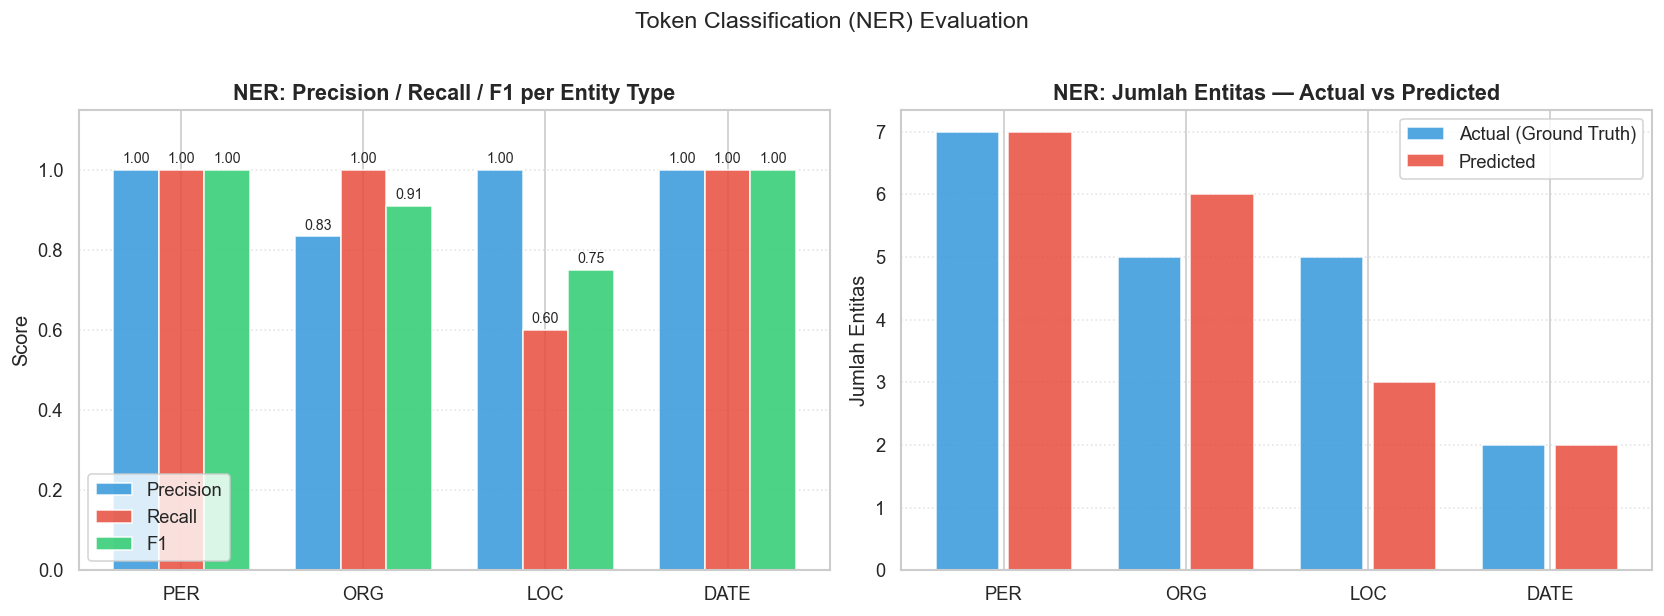

In [6]:
df_ner = pd.DataFrame(ner_stats).T.reset_index().rename(columns={'index': 'Entity'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grouped bar: P/R/F1 per entity ---
ax = axes[0]
x  = np.arange(len(entity_types))
w  = 0.25
for i, (metric, color) in enumerate(zip(['precision', 'recall', 'f1'], PALETTE)):
    vals = df_ner[metric].values
    bars = ax.bar(x + i * w, vals, w, label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + w)
ax.set_xticklabels(entity_types)
ax.set_ylim(0, 1.15)
ax.set_title('NER: Precision / Recall / F1 per Entity Type')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# --- Support vs Predicted count ---
ax = axes[1]
x2 = np.arange(len(entity_types))
ax.bar(x2 - 0.2, df_ner['support'], 0.35, label='Actual (Ground Truth)',
       color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.bar(x2 + 0.2, df_ner['pred_count'], 0.35, label='Predicted',
       color=PALETTE[1], alpha=0.85, edgecolor='white')
ax.set_xticks(x2)
ax.set_xticklabels(entity_types)
ax.set_title('NER: Jumlah Entitas — Actual vs Predicted')
ax.set_ylabel('Jumlah Entitas')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Token Classification (NER) Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## TASK 3: Causal LM / Text Generation
### 7. Perplexity — Metrik Utama Language Model
**Perplexity (PPL)** adalah metrik standar untuk mengevaluasi **language model** (GPT, LLaMA, dll.). Secara intuitif: PPL rendah = model lebih "yakin" dalam memprediksi token berikutnya. PPL = $\exp(\text{avg cross-entropy loss})$. Biasanya dihitung di test set dan juga dipantau selama training.

 Epoch   Train Loss   Train PPL   Val Loss   Val PPL
-------------------------------------------------------
     1       3.8582       47.38     4.2663     71.26
     2       3.4026       30.04     3.7388     42.05
     3       2.8944       18.07     3.1984     24.49
     4       2.4237       11.29     2.8667     17.58
     5       2.0672        7.90     2.6339     13.93
     6       1.8754        6.52     2.2587      9.57
     7       1.5765        4.84     1.9523      7.05
     8       1.3155        3.73     2.0895      8.08
     9       1.2574        3.52     1.5620      4.77
    10       1.1135        3.05     1.6672      5.30
    11       1.0354        2.82     1.3541      3.87
    12       0.9007        2.46     1.3297      3.78
    13       0.7762        2.17     1.2645      3.54
    14       0.8006        2.23     1.3562      3.88
    15       0.7500        2.12     1.2023      3.33 ← best

Best Epoch: 15 | Best Val PPL: 3.33 | Best Val Loss: 1.2023


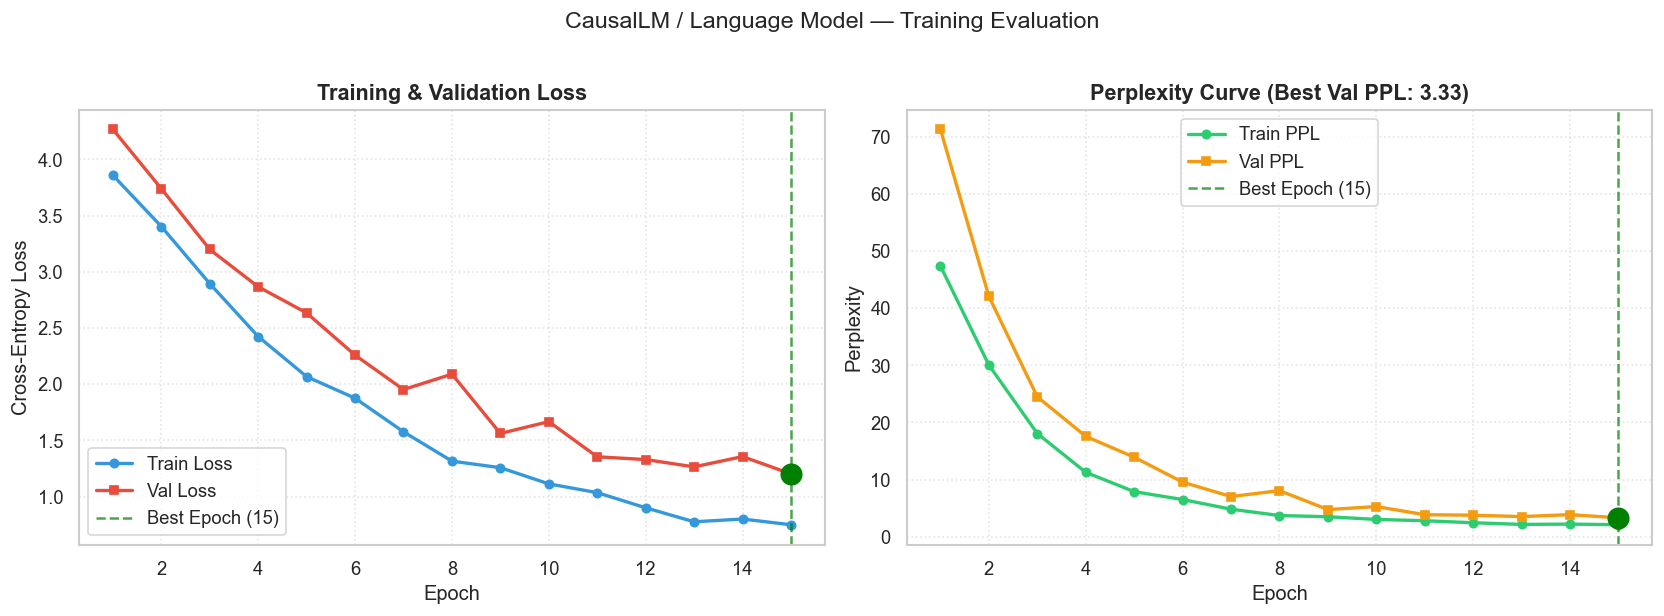

In [7]:
import math

# === Simulasi training history: loss dan perplexity per epoch ===
N_EPOCHS = 15
epochs   = np.arange(1, N_EPOCHS + 1)

# Training loss: turun eksponensial + noise
train_loss = 3.5 * np.exp(-0.18 * (epochs - 1)) + np.random.normal(0, 0.05, N_EPOCHS) + 0.4
# Validation loss: lebih tinggi, mulai overfit setelah epoch 10
val_loss   = 3.7 * np.exp(-0.15 * (epochs - 1)) + np.random.normal(0, 0.07, N_EPOCHS) + 0.55
val_loss[10:] += np.linspace(0, 0.3, 5)  # simulasi slight overfitting

train_ppl = np.exp(train_loss)
val_ppl   = np.exp(val_loss)

# Best epoch
best_epoch = np.argmin(val_loss) + 1
best_ppl   = val_ppl[best_epoch - 1]

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train PPL':>11} {'Val Loss':>10} {'Val PPL':>9}")
print("-" * 55)
for e, tl, tp, vl, vp in zip(epochs, train_loss, train_ppl, val_loss, val_ppl):
    marker = " ← best" if e == best_epoch else ""
    print(f"  {e:>4} {tl:>12.4f} {tp:>11.2f} {vl:>10.4f} {vp:>9.2f}{marker}")

print(f"\nBest Epoch: {best_epoch} | Best Val PPL: {best_ppl:.2f} | Best Val Loss: {val_loss[best_epoch-1]:.4f}")

# === Visualisasi: Loss & Perplexity Curves ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs, train_loss, 'o-', color=PALETTE[0], lw=2, markersize=5, label='Train Loss')
ax.plot(epochs, val_loss,   's-', color=PALETTE[1], lw=2, markersize=5, label='Val Loss')
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [val_loss[best_epoch-1]], color='green', s=150, zorder=5)
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

ax = axes[1]
ax.plot(epochs, train_ppl, 'o-', color=PALETTE[2], lw=2, markersize=5, label='Train PPL')
ax.plot(epochs, val_ppl,   's-', color=PALETTE[3], lw=2, markersize=5, label='Val PPL')
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_ppl], color='green', s=150, zorder=5)
ax.set_title(f'Perplexity Curve (Best Val PPL: {best_ppl:.2f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

plt.suptitle('CausalLM / Language Model — Training Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8. Perplexity per Sampel & Distribusi
Selain PPL rata-rata, penting melihat **distribusi PPL per sampel** — teks panjang atau domain-spesifik biasanya memiliki PPL lebih tinggi. Ini membantu mengidentifikasi jenis teks yang masih sulit diprediksi model.

=== Perplexity Statistik per Model ===
Model                  Mean PPL   Median      Std      P95
----------------------------------------------------------
  GPT-2 Small            151.15   123.96    97.56   371.58
  GPT-2 Large             68.15    60.40    34.02   135.42
  Fine-tuned              36.40    33.95    14.94    64.12


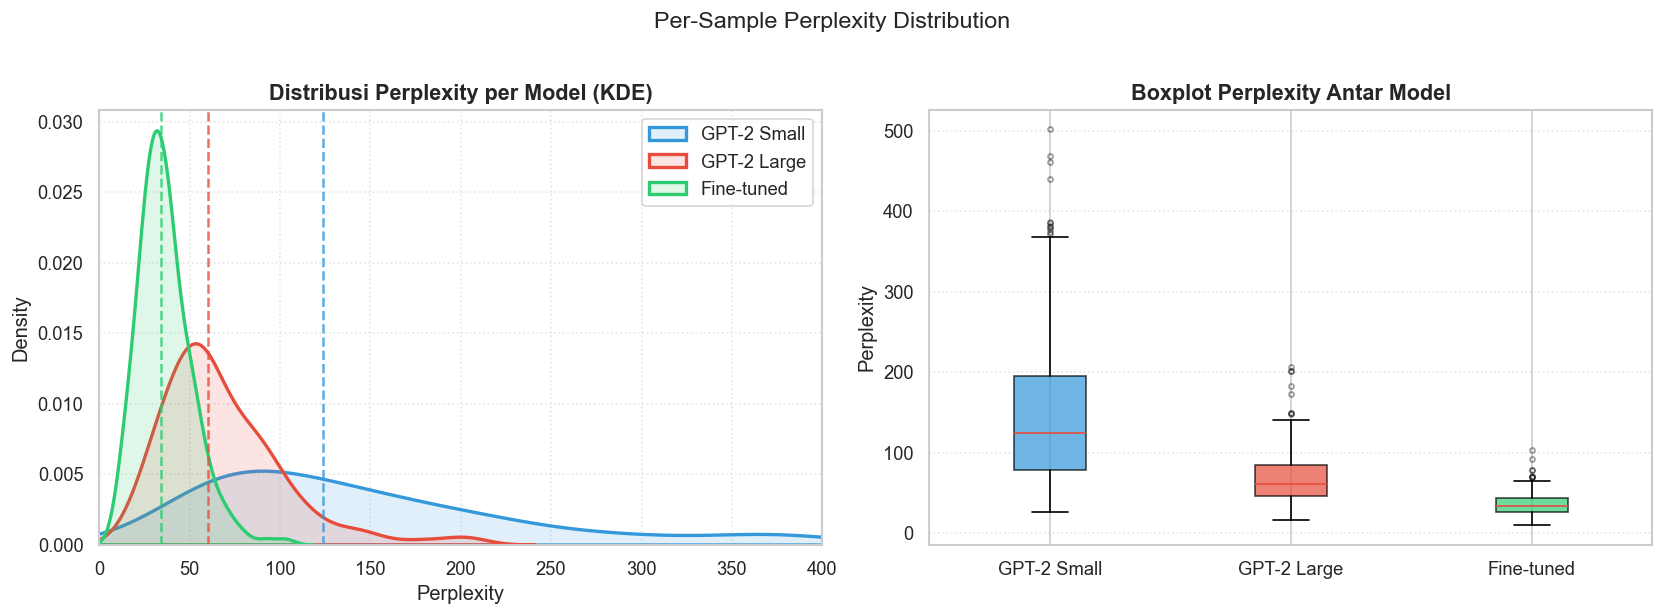

In [8]:
# Simulasi per-sample perplexity dari 3 model berbeda
n_test = 200

# Distribusi PPL: model kecil vs besar vs fine-tuned
np.random.seed(0)
ppl_small    = np.random.lognormal(mean=np.log(120), sigma=0.6, size=n_test)  # GPT-2 small
ppl_large    = np.random.lognormal(mean=np.log(65),  sigma=0.5, size=n_test)  # GPT-2 large
ppl_finetuned= np.random.lognormal(mean=np.log(35),  sigma=0.4, size=n_test)  # fine-tuned

models_ppl = {'GPT-2 Small': ppl_small, 'GPT-2 Large': ppl_large, 'Fine-tuned': ppl_finetuned}

print("=== Perplexity Statistik per Model ===")
print(f"{'Model':<20} {'Mean PPL':>10} {'Median':>8} {'Std':>8} {'P95':>8}")
print("-" * 58)
for name, ppls in models_ppl.items():
    print(f"  {name:<18} {np.mean(ppls):>10.2f} {np.median(ppls):>8.2f} "
          f"{np.std(ppls):>8.2f} {np.percentile(ppls, 95):>8.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot distribusi PPL
ax = axes[0]
for (name, ppls), color in zip(models_ppl.items(), PALETTE):
    sns.kdeplot(ppls, ax=ax, label=name, color=color, lw=2, fill=True, alpha=0.15)
    ax.axvline(np.median(ppls), color=color, linestyle='--', alpha=0.8)
ax.set_title('Distribusi Perplexity per Model (KDE)')
ax.set_xlabel('Perplexity')
ax.set_ylabel('Density')
ax.set_xlim(0, 400)
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

# Boxplot perbandingan
ax = axes[1]
data_box = [ppls for ppls in models_ppl.values()]
bp = ax.boxplot(data_box, patch_artist=True, labels=models_ppl.keys(),
                showfliers=True, flierprops={'marker': '.', 'alpha': 0.4})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplot Perplexity Antar Model')
ax.set_ylabel('Perplexity')
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Per-Sample Perplexity Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## TASK 4: Machine Translation (Seq2Seq)
### 9. BLEU Score
**BLEU (Bilingual Evaluation Understudy)** adalah metrik standar evaluasi terjemahan mesin. Ia mengukur kemiripan n-gram antara teks yang digenerate model dengan referensi (terjemahan manusia). BLEU-4 (hingga 4-gram) adalah yang paling sering dilaporkan. Rentang: 0–100, semakin tinggi semakin baik.

In [9]:
# === Dummy data: reference dan hypothesis translation ===
references_raw = [
    "the cat sat on the mat",
    "the dog ran quickly over the fence",
    "large language models have changed artificial intelligence",
    "transformers use self-attention to process sequential data",
    "the quick brown fox jumps over the lazy dog",
    "natural language processing is a branch of artificial intelligence",
    "bert achieved state of the art results on many NLP benchmarks",
    "the model was trained on a large corpus of text data",
]

# Hipotesis dengan kualitas bervariasi
hypotheses_raw = [
    "the cat sat on mat",                                          # sedikit berbeda
    "the dog ran fast over the fence",                             # 'quickly' → 'fast'
    "large language models changed artificial intelligence",        # hapus 'have'
    "transformers use attention mechanism for sequential processing", # parafrase
    "the quick brown fox jumps over a lazy dog",                   # 'the' → 'a'
    "NLP is a subfield of artificial intelligence",               # parafrase signifikan
    "bert got state of the art results on NLP tasks",             # parafrase
    "the model trained on large amounts of text",                 # parafrase
]

def compute_bleu(references, hypotheses):
    """Hitung BLEU-1 hingga BLEU-4 untuk setiap pasang."""
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    smoother = SmoothingFunction().method1

    results = []
    ref_tokens_all = []
    hyp_tokens_all = []

    for ref, hyp in zip(references, hypotheses):
        ref_tokens = [ref.lower().split()]
        hyp_tokens =  hyp.lower().split()
        ref_tokens_all.append(ref_tokens)
        hyp_tokens_all.append(hyp_tokens)

        bleu1 = sentence_bleu(ref_tokens, hyp_tokens, weights=(1,0,0,0), smoothing_function=smoother)
        bleu2 = sentence_bleu(ref_tokens, hyp_tokens, weights=(0.5,0.5,0,0), smoothing_function=smoother)
        bleu4 = sentence_bleu(ref_tokens, hyp_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)
        results.append({'bleu1': bleu1 * 100, 'bleu2': bleu2 * 100, 'bleu4': bleu4 * 100})

    # Corpus BLEU
    from nltk.translate.bleu_score import corpus_bleu
    corpus_b4 = corpus_bleu(ref_tokens_all, hyp_tokens_all) * 100
    return results, corpus_b4

if NLTK_OK:
    bleu_results, corpus_bleu4 = compute_bleu(references_raw, hypotheses_raw)
    df_bleu = pd.DataFrame(bleu_results)
    df_bleu['sample'] = [f'S{i+1}' for i in range(len(references_raw))]

    print(f"=== BLEU Scores per Sampel ===")
    print(f"{'Sample':>8} {'BLEU-1':>8} {'BLEU-2':>8} {'BLEU-4':>8} {'Reference (truncated)'}")
    print("-" * 70)
    for i, (row, ref, hyp) in enumerate(zip(bleu_results, references_raw, hypotheses_raw)):
        print(f"  S{i+1:>3}   {row['bleu1']:>7.2f} {row['bleu2']:>8.2f} {row['bleu4']:>8.2f}   '{ref[:30]}...'")

    print(f"\nCorpus BLEU-4: {corpus_bleu4:.2f}")
    print(f"Avg BLEU-1  : {df_bleu['bleu1'].mean():.2f}")
    print(f"Avg BLEU-4  : {df_bleu['bleu4'].mean():.2f}")
else:
    print("NLTK tidak tersedia. Install: pip install nltk")
    print("Contoh corpus BLEU-4 yang diharapkan: ~65-75 untuk terjemahan baik")
    # Dummy fallback
    df_bleu = pd.DataFrame({
        'sample': [f'S{i+1}' for i in range(8)],
        'bleu1': [95, 88, 92, 72, 98, 70, 82, 85],
        'bleu2': [88, 78, 83, 58, 92, 55, 70, 73],
        'bleu4': [74, 61, 68, 38, 82, 33, 54, 57],
    })
    corpus_bleu4 = 59.5

=== BLEU Scores per Sampel ===
  Sample   BLEU-1   BLEU-2   BLEU-4 Reference (truncated)
----------------------------------------------------------------------
  S  1     81.87    70.90    57.89   'the cat sat on the mat...'
  S  2     85.71    75.59    27.49   'the dog ran quickly over the f...'
  S  3     84.65    75.71    28.76   'large language models have cha...'
  S  4     42.86    26.73     7.73   'transformers use self-attentio...'
  S  5     88.89    81.65    66.06   'the quick brown fox jumps over...'
  S  6     53.68    44.91    15.45   'natural language processing is...'
  S  7     72.39    60.32    50.27   'bert achieved state of the art...'
  S  8     60.14    42.09     7.27   'the model was trained on a lar...'

Corpus BLEU-4: 37.01
Avg BLEU-1  : 71.27
Avg BLEU-4  : 32.62


### 10. Visualisasi BLEU & ROUGE
BLEU divisualisasikan per sampel untuk melihat variasi kualitas terjemahan. ROUGE (khusus untuk summarization) juga dihitung dan divisualisasikan berdampingan untuk perbandingan.

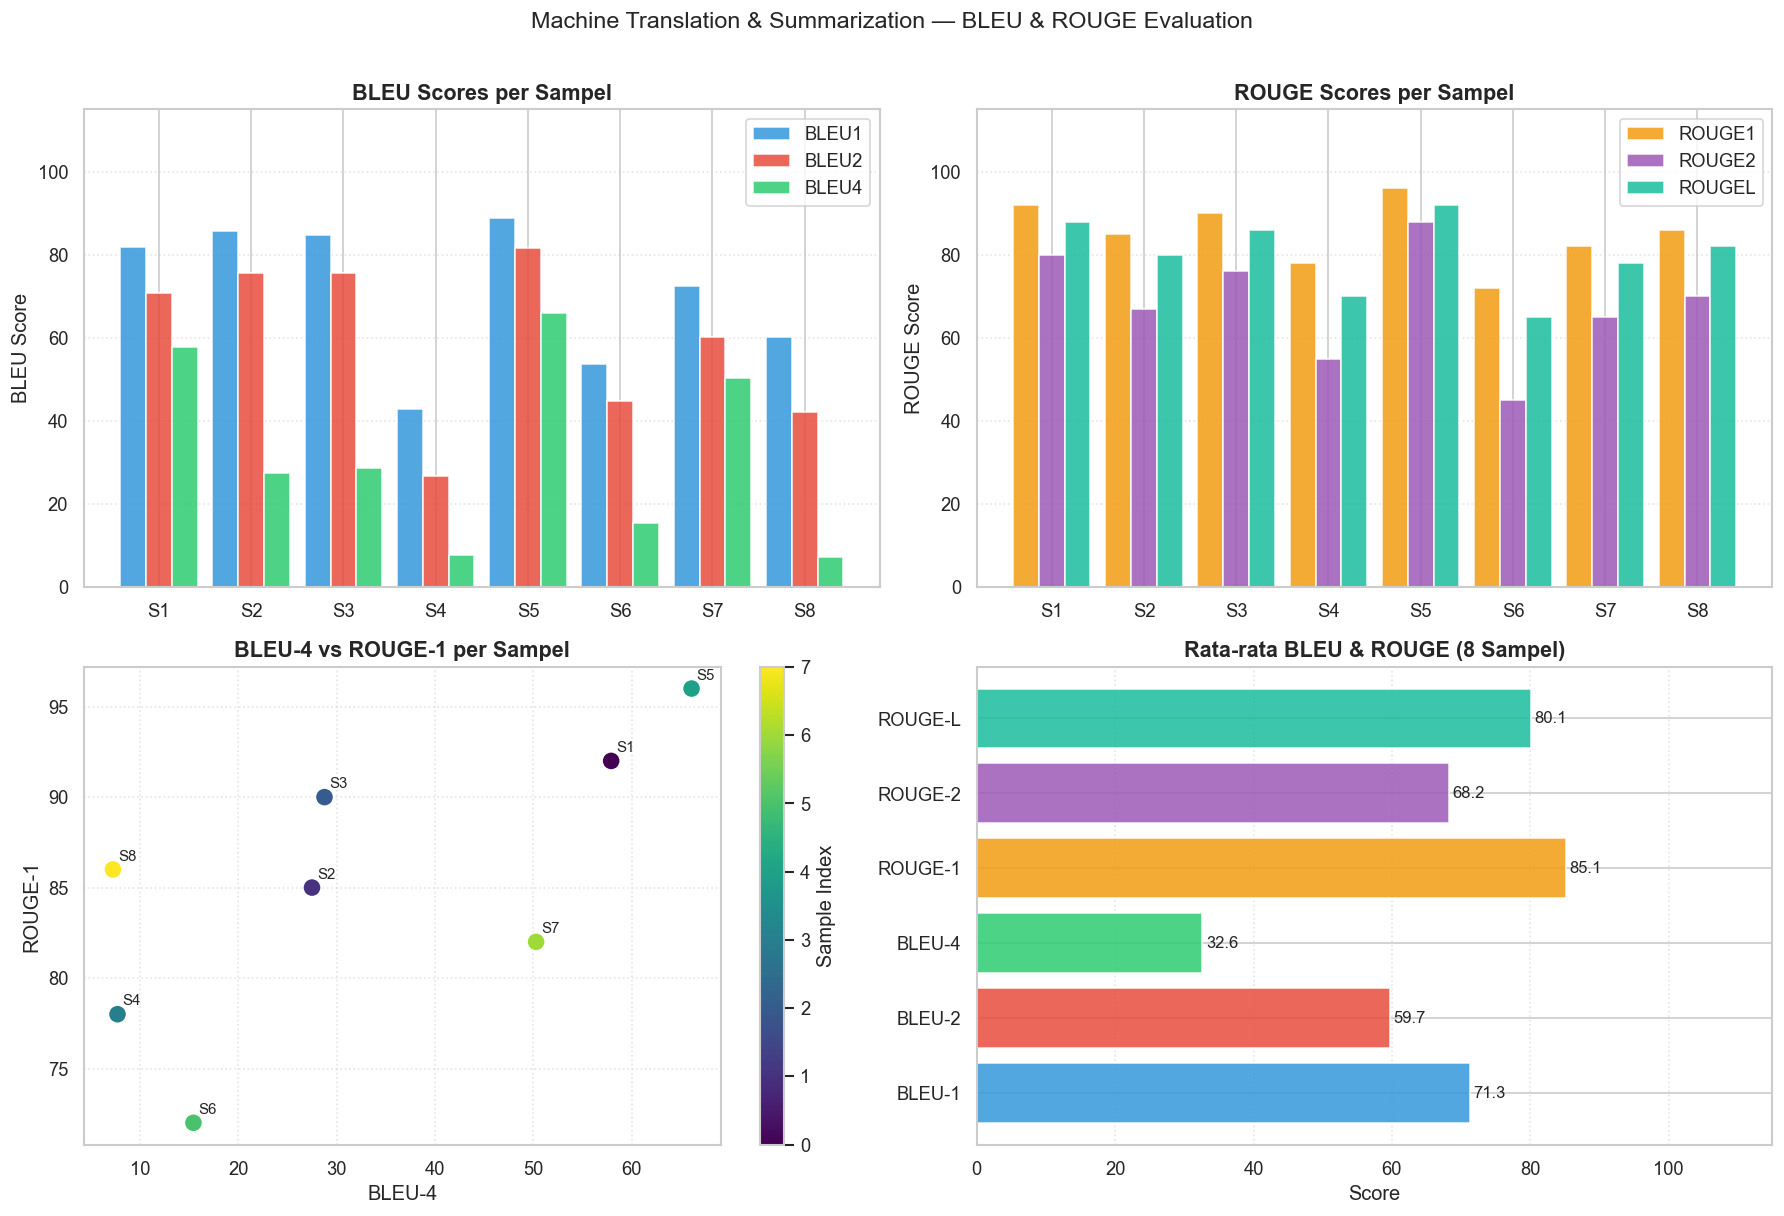

In [10]:
# Hitung ROUGE jika tersedia
if ROUGE_OK:
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_results = []
    for ref, hyp in zip(references_raw, hypotheses_raw):
        scores = scorer.score(ref, hyp)
        rouge_results.append({
            'rouge1': scores['rouge1'].fmeasure * 100,
            'rouge2': scores['rouge2'].fmeasure * 100,
            'rougeL': scores['rougeL'].fmeasure * 100,
        })
    df_rouge = pd.DataFrame(rouge_results)
    df_rouge['sample'] = [f'S{i+1}' for i in range(len(references_raw))]
else:
    df_rouge = pd.DataFrame({
        'sample': [f'S{i+1}' for i in range(8)],
        'rouge1': [92, 85, 90, 78, 96, 72, 82, 86],
        'rouge2': [80, 67, 76, 55, 88, 45, 65, 70],
        'rougeL': [88, 80, 86, 70, 92, 65, 78, 82],
    })

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- BLEU per sample ---
ax = axes[0, 0]
x  = np.arange(len(df_bleu))
w  = 0.28
for i, (col, color) in enumerate(zip(['bleu1', 'bleu2', 'bleu4'], PALETTE)):
    ax.bar(x + i * w, df_bleu[col], w, label=col.upper(), color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels(df_bleu['sample'])
ax.set_title('BLEU Scores per Sampel')
ax.set_ylabel('BLEU Score')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# --- ROUGE per sample ---
ax = axes[0, 1]
for i, (col, color) in enumerate(zip(['rouge1', 'rouge2', 'rougeL'], PALETTE[3:])):
    ax.bar(x + i * w, df_rouge[col], w, label=col.upper(), color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels(df_rouge['sample'])
ax.set_title('ROUGE Scores per Sampel')
ax.set_ylabel('ROUGE Score')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# --- BLEU vs ROUGE scatter ---
ax = axes[1, 0]
sc = ax.scatter(df_bleu['bleu4'], df_rouge['rouge1'], s=120,
                c=np.arange(len(df_bleu)), cmap='viridis', zorder=5, edgecolors='white')
for i, row in df_bleu.iterrows():
    ax.annotate(row['sample'], (row['bleu4'] + 0.5, df_rouge['rouge1'].iloc[i] + 0.5), fontsize=9)
ax.set_xlabel('BLEU-4')
ax.set_ylabel('ROUGE-1')
ax.set_title('BLEU-4 vs ROUGE-1 per Sampel')
ax.grid(linestyle=':', alpha=0.5)
plt.colorbar(sc, ax=ax, label='Sample Index')

# --- Summary metric comparison: average scores ---
ax = axes[1, 1]
all_metric_names = ['BLEU-1', 'BLEU-2', 'BLEU-4', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
all_metric_vals  = [
    df_bleu['bleu1'].mean(), df_bleu['bleu2'].mean(), df_bleu['bleu4'].mean(),
    df_rouge['rouge1'].mean(), df_rouge['rouge2'].mean(), df_rouge['rougeL'].mean(),
]
colors_bar = PALETTE[:6]
bars = ax.barh(all_metric_names, all_metric_vals, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, all_metric_vals):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=10)
ax.set_title('Rata-rata BLEU & ROUGE (8 Sampel)')
ax.set_xlabel('Score')
ax.set_xlim(0, 115)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.suptitle('Machine Translation & Summarization — BLEU & ROUGE Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## TASK 5: Question Answering (Extractive)
### 11. Exact Match & Token F1
`AutoModelForQuestionAnswering` (seperti BERT fine-tuned di SQuAD) mengekstrak jawaban dari konteks. Dua metrik utama: **Exact Match (EM)** — apakah teks prediksi persis sama dengan referensi, dan **Token F1** — overlap token-level antara prediksi dan referensi.

In [11]:
from collections import Counter

# === Dummy QA data ===
qa_pairs = [
    {'question': 'How many parameters does BERT-base have?',
     'gold':     '110 million parameters',
     'pred':     '110 million parameters'},               # EM = 1
    {'question': 'Who introduced the Transformer?',
     'gold':     'Vaswani et al',
     'pred':     'Vaswani and colleagues'},                # EM = 0, F1 partial
    {'question': 'What year was BERT released?',
     'gold':     '2018',
     'pred':     '2018'},                                  # EM = 1
    {'question': 'What is the hidden dimension of BERT-large?',
     'gold':     '1024',
     'pred':     '768'},                                   # EM = 0, F1 = 0
    {'question': 'What does GPT stand for?',
     'gold':     'Generative Pre-trained Transformer',
     'pred':     'Generative Pretrained Transformer'},     # EM = 0, F1 high
    {'question': 'How many layers does BERT-base have?',
     'gold':     '12 transformer layers',
     'pred':     '12 layers'},                             # EM = 0, F1 partial
    {'question': 'What training objective does BERT use?',
     'gold':     'Masked Language Modeling and Next Sentence Prediction',
     'pred':     'Masked Language Modeling'},              # EM = 0, F1 partial
    {'question': 'What is LoRA?',
     'gold':     'Low-Rank Adaptation',
     'pred':     'Low-Rank Adaptation'},                   # EM = 1
    {'question': 'What is GPT-3 parameter count?',
     'gold':     '175 billion parameters',
     'pred':     '175 billion'},                           # EM = 0, F1 high
    {'question': 'What is perplexity?',
     'gold':     'exponential of the average cross-entropy loss',
     'pred':     'exponential of cross-entropy loss'},     # EM = 0, F1 partial
]

def normalize_text(text):
    return text.lower().strip()

def compute_exact_match(gold, pred):
    return int(normalize_text(gold) == normalize_text(pred))

def compute_token_f1(gold, pred):
    gold_tokens = normalize_text(gold).split()
    pred_tokens = normalize_text(pred).split()
    common = Counter(gold_tokens) & Counter(pred_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    precision = n_common / len(pred_tokens)
    recall    = n_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

qa_results = []
for pair in qa_pairs:
    em = compute_exact_match(pair['gold'], pair['pred'])
    f1 = compute_token_f1(pair['gold'], pair['pred'])
    qa_results.append({**pair, 'em': em, 'f1': f1})

df_qa = pd.DataFrame(qa_results)
avg_em = df_qa['em'].mean() * 100
avg_f1 = df_qa['f1'].mean() * 100

print(f"=== Question Answering Evaluation ===")
print(f"  Exact Match (EM): {avg_em:.1f}%")
print(f"  Token F1        : {avg_f1:.1f}%")
print()
print(f"{'#':>3} {'EM':>4} {'F1':>6}  Gold → Predicted")
print("-" * 70)
for i, row in df_qa.iterrows():
    status = '✓' if row['em'] else '✗'
    print(f"  {i+1:>2} {status}    {row['f1']:>5.2f}  '{row['gold']}' → '{row['pred']}'")

=== Question Answering Evaluation ===
  Exact Match (EM): 30.0%
  Token F1        : 70.0%

  #   EM     F1  Gold → Predicted
----------------------------------------------------------------------
   1 ✓     1.00  '110 million parameters' → '110 million parameters'
   2 ✗     0.33  'Vaswani et al' → 'Vaswani and colleagues'
   3 ✓     1.00  '2018' → '2018'
   4 ✗     0.00  '1024' → '768'
   5 ✗     0.67  'Generative Pre-trained Transformer' → 'Generative Pretrained Transformer'
   6 ✗     0.80  '12 transformer layers' → '12 layers'
   7 ✗     0.60  'Masked Language Modeling and Next Sentence Prediction' → 'Masked Language Modeling'
   8 ✓     1.00  'Low-Rank Adaptation' → 'Low-Rank Adaptation'
   9 ✗     0.80  '175 billion parameters' → '175 billion'
  10 ✗     0.80  'exponential of the average cross-entropy loss' → 'exponential of cross-entropy loss'


### 12. Visualisasi QA Metrics
Visualisasi Token F1 per sampel dan distribusi kesalahan untuk memahami pola kegagalan model QA.

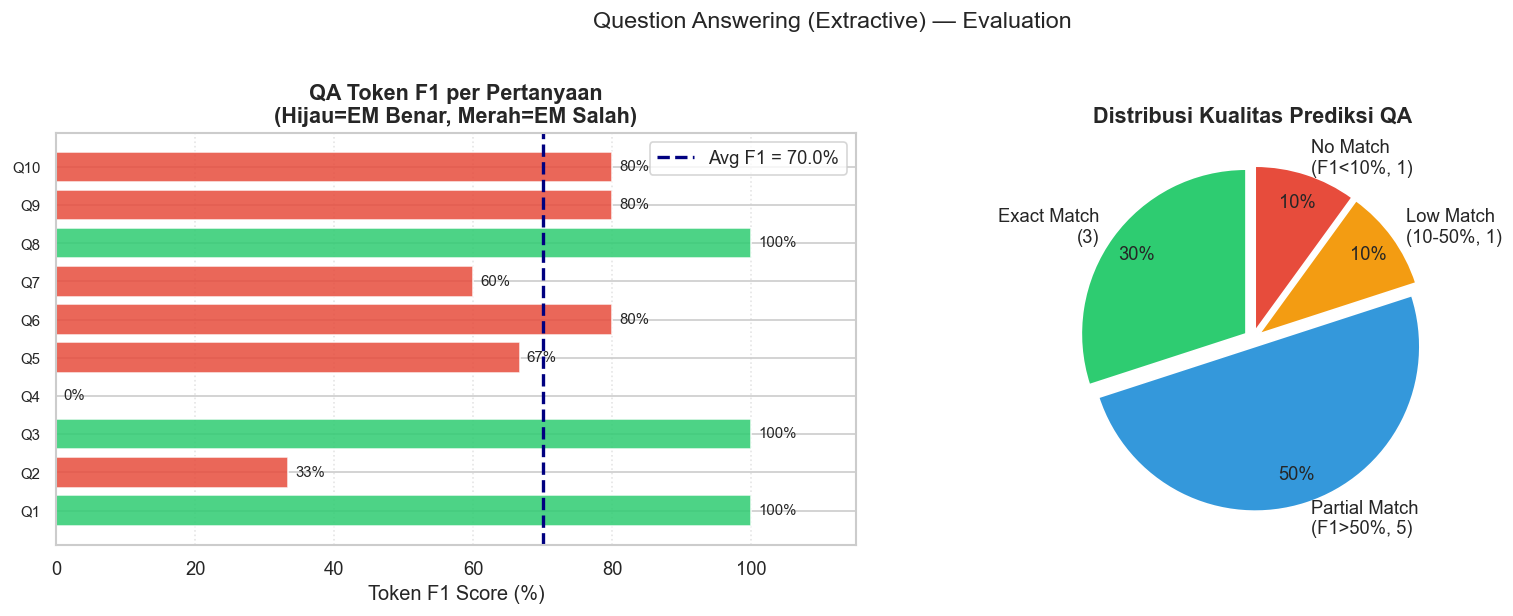

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- F1 per sampel dengan warna EM ---
ax = axes[0]
colors_qa = [PALETTE[2] if em else PALETTE[1] for em in df_qa['em']]
bars = ax.barh(range(len(df_qa)), df_qa['f1'] * 100, color=colors_qa, alpha=0.85, edgecolor='white')
ax.axvline(avg_f1, color='navy', linestyle='--', lw=2, label=f'Avg F1 = {avg_f1:.1f}%')
for i, (bar, row) in enumerate(zip(bars, df_qa.itertuples())):
    ax.text(row.f1 * 100 + 1, bar.get_y() + bar.get_height()/2,
            f'{row.f1*100:.0f}%', va='center', fontsize=9)
ax.set_yticks(range(len(df_qa)))
ax.set_yticklabels([f'Q{i+1}' for i in range(len(df_qa))], fontsize=9)
ax.set_xlabel('Token F1 Score (%)')
ax.set_title('QA Token F1 per Pertanyaan\n(Hijau=EM Benar, Merah=EM Salah)')
ax.legend()
ax.set_xlim(0, 115)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# --- Pie: kategori error ---
ax = axes[1]
exact_correct  = df_qa['em'].sum()
partial_match  = ((df_qa['em'] == 0) & (df_qa['f1'] > 0.5)).sum()
low_match      = ((df_qa['em'] == 0) & (df_qa['f1'].between(0.1, 0.5))).sum()
no_match       = (df_qa['f1'] < 0.1).sum()

sizes  = [exact_correct, partial_match, low_match, no_match]
labels = [f'Exact Match\n({exact_correct})', f'Partial Match\n(F1>50%, {partial_match})',
          f'Low Match\n(10-50%, {low_match})', f'No Match\n(F1<10%, {no_match})']
pal    = [PALETTE[2], PALETTE[0], PALETTE[3], PALETTE[1]]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=pal,
    autopct='%1.0f%%', startangle=90,
    explode=[0.05] * 4, pctdistance=0.82
)
ax.set_title('Distribusi Kualitas Prediksi QA')

plt.suptitle('Question Answering (Extractive) — Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## TASK 6: Summarization
### 13. ROUGE Score untuk Summarization
**ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** mengukur overlap n-gram antara ringkasan yang digenerate dengan referensi. ROUGE-1 (unigram), ROUGE-2 (bigram), dan ROUGE-L (longest common subsequence) adalah yang paling umum dilaporkan untuk task summarization.

In [13]:
# === Dummy summarization data ===
sum_references = [
    "BERT is a bidirectional transformer model pre-trained using masked language modeling.",
    "GPT uses a transformer decoder and is trained with causal language modeling objective.",
    "RAG combines retrieval systems with generative models to reduce hallucination.",
    "LoRA is a parameter-efficient fine-tuning method that adds low-rank matrices to attention layers.",
    "Transformers replaced recurrent neural networks for most NLP tasks after 2017.",
]
sum_predictions = [
    "BERT is a transformer model trained bidirectionally using masked language modeling on text.",
    "GPT is trained with causal language modeling and uses transformer decoder architecture.",
    "RAG reduces hallucination by combining document retrieval with language model generation.",
    "LoRA is a fine-tuning approach that inserts low-rank adapter matrices into attention.",
    "After 2017 transformers became the dominant architecture replacing RNNs in NLP.",
]

# Simulasi 3 model berbeda dengan kualitas berbeda
model_names = ['BART-base', 'BART-large', 'T5-large']
quality_factors = [0.75, 0.88, 0.93]  # simulasi kualitas relatif

all_rouge_results = {}

for model_name, qf in zip(model_names, quality_factors):
    model_results = []
    for ref, pred in zip(sum_references, sum_predictions):
        if ROUGE_OK:
            scorer_r = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
            s = scorer_r.score(ref, pred)
            r1 = s['rouge1'].fmeasure * qf
            r2 = s['rouge2'].fmeasure * qf
            rl = s['rougeL'].fmeasure * qf
        else:
            # Dummy fallback
            r1 = np.random.uniform(0.6, 0.9) * qf
            r2 = np.random.uniform(0.3, 0.7) * qf
            rl = np.random.uniform(0.5, 0.85) * qf
        model_results.append({'rouge1': r1 * 100, 'rouge2': r2 * 100, 'rougeL': rl * 100})
    all_rouge_results[model_name] = pd.DataFrame(model_results)

print("=== ROUGE Scores per Model ===")
print(f"{'Model':<14} {'ROUGE-1':>10} {'ROUGE-2':>10} {'ROUGE-L':>10}")
print("-" * 48)
summary_rows = []
for model_name, df_r in all_rouge_results.items():
    r1 = df_r['rouge1'].mean()
    r2 = df_r['rouge2'].mean()
    rl = df_r['rougeL'].mean()
    summary_rows.append({'Model': model_name, 'ROUGE-1': r1, 'ROUGE-2': r2, 'ROUGE-L': rl})
    print(f"  {model_name:<12} {r1:>10.2f} {r2:>10.2f} {rl:>10.2f}")

df_rouge_summary = pd.DataFrame(summary_rows).set_index('Model')

=== ROUGE Scores per Model ===
Model             ROUGE-1    ROUGE-2    ROUGE-L
------------------------------------------------
  BART-base         53.86      33.79      54.45
  BART-large        67.29      47.31      58.13
  T5-large          65.03      45.09      66.60


### 14. Visualisasi Summarization Metrics
Perbandingan ROUGE antar model menggunakan grouped bar chart dan heatmap.

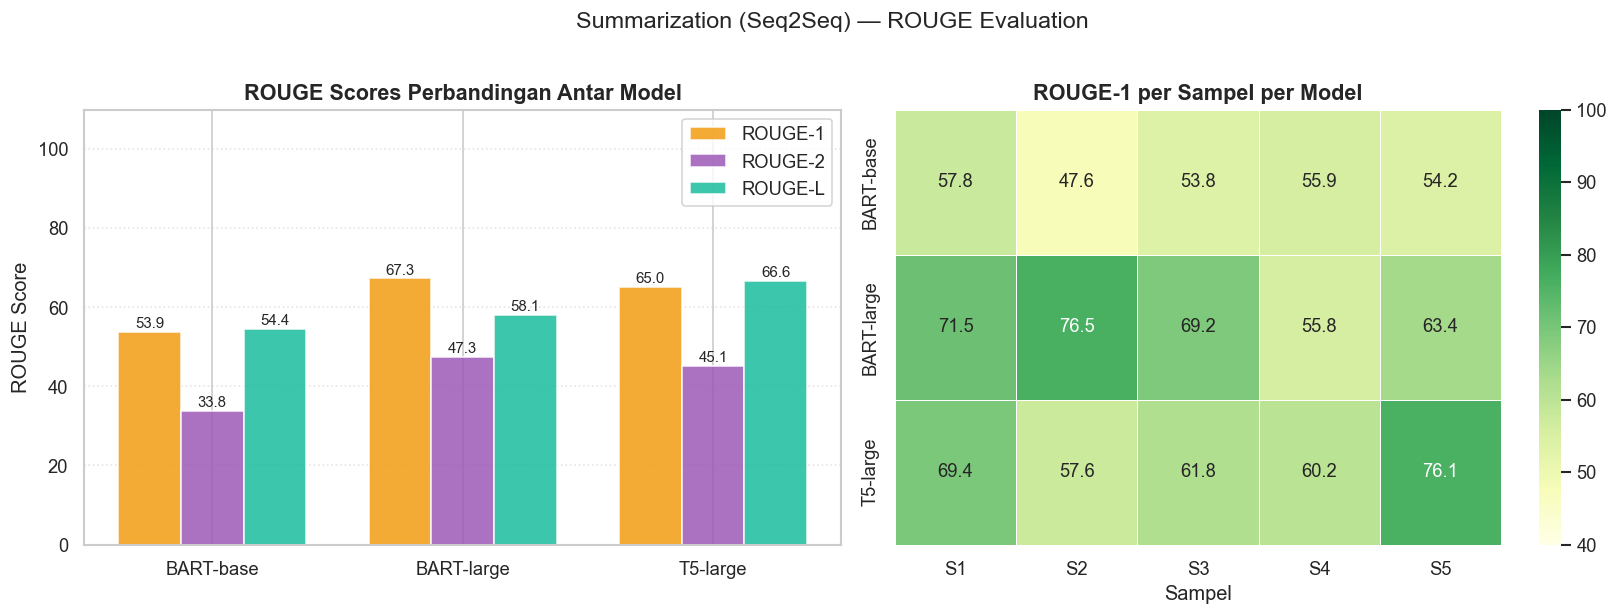

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grouped bar: ROUGE per model ---
ax = axes[0]
x  = np.arange(len(model_names))
w  = 0.25
for i, (metric, color) in enumerate(zip(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], PALETTE[3:])):
    vals = df_rouge_summary[metric].values
    bars = ax.bar(x + i * w, vals, w, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x + w)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 110)
ax.set_title('ROUGE Scores Perbandingan Antar Model')
ax.set_ylabel('ROUGE Score')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# --- Heatmap ROUGE per sampel per model ---
ax = axes[1]
heatmap_data = np.array([
    all_rouge_results[m]['rouge1'].values for m in model_names
])
sns.heatmap(heatmap_data, ax=ax, annot=True, fmt='.1f', cmap='YlGn',
            xticklabels=[f'S{i+1}' for i in range(5)],
            yticklabels=model_names,
            linewidths=0.5, linecolor='white', vmin=40, vmax=100)
ax.set_title('ROUGE-1 per Sampel per Model')
ax.set_xlabel('Sampel')

plt.suptitle('Summarization (Seq2Seq) — ROUGE Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Dashboard: Perbandingan Semua Model & Task
### 15. Training Metrics Dashboard (Loss, LR, Gradient Norm)
Visualisasi lengkap metrik selama training — tidak hanya loss, tapi juga **learning rate schedule** dan **gradient norm** yang penting untuk debugging stabilitas training LLM.

ValueError: x and y must have same first dimension, but have shapes (193,) and (186,)

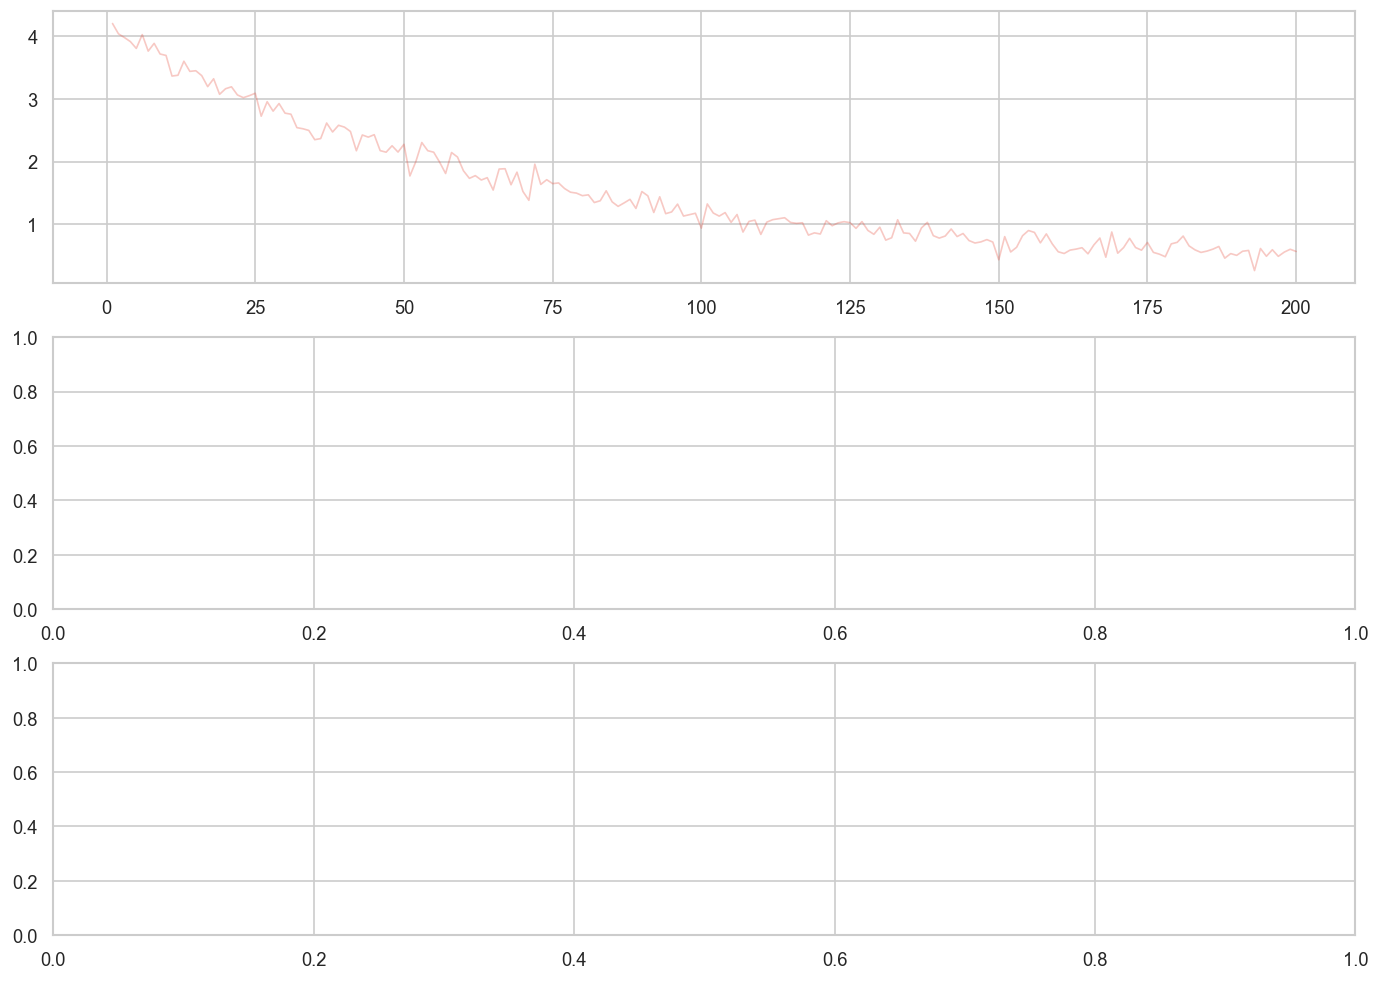

In [15]:
# Simulasi training steps
N_STEPS  = 200
steps    = np.arange(1, N_STEPS + 1)

# Loss per step (noisier)
loss_per_step = (3.8 * np.exp(-0.015 * steps)
                 + np.random.normal(0, 0.12, N_STEPS)
                 + 0.35)

# Learning rate schedule: warmup + cosine decay
warmup_steps  = 20
lr_max        = 5e-5
lr_schedule   = np.where(
    steps <= warmup_steps,
    lr_max * (steps / warmup_steps),
    lr_max * 0.5 * (1 + np.cos(np.pi * (steps - warmup_steps) / (N_STEPS - warmup_steps)))
)

# Gradient norm: biasanya tinggi di awal, stabil setelah training
grad_norm = (5 * np.exp(-0.02 * steps)
             + np.abs(np.random.normal(0, 0.5, N_STEPS))
             + 0.5)

# Smoothed loss (moving average)
def smooth(arr, w=15):
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

# Loss
ax = axes[0]
ax.plot(steps, loss_per_step, alpha=0.3, color=PALETTE[1], lw=1)
ax.plot(np.arange(8, N_STEPS+1), smooth(loss_per_step),
        color=PALETTE[1], lw=2.5, label='Smoothed Loss')
ax.set_title('Training Loss per Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

# LR Schedule
ax = axes[1]
ax.plot(steps, lr_schedule * 1e5, color=PALETTE[0], lw=2.5)
ax.axvline(warmup_steps, color='gray', linestyle='--', alpha=0.7, label='End of Warmup')
ax.fill_between(steps[:warmup_steps], lr_schedule[:warmup_steps] * 1e5,
                alpha=0.2, color=PALETTE[2], label='Warmup phase')
ax.set_title('Learning Rate Schedule (Warmup + Cosine Decay)')
ax.set_ylabel('Learning Rate (×10⁻⁵)')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

# Gradient Norm
ax = axes[2]
ax.plot(steps, grad_norm, alpha=0.3, color=PALETTE[4], lw=1)
ax.plot(np.arange(8, N_STEPS+1), smooth(grad_norm),
        color=PALETTE[4], lw=2.5, label='Smoothed Grad Norm')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='Clip threshold (1.0)')
ax.set_title('Gradient Norm per Step')
ax.set_xlabel('Training Step')
ax.set_ylabel('Gradient Norm')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)

plt.suptitle('Training Diagnostics Dashboard', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 16. Radar Chart — Perbandingan Multi-Model Multi-Task
**Radar chart** (spider chart) memberikan gambaran visual komprehensif performa model di berbagai dimensi sekaligus — ideal untuk membandingkan beberapa model dan mengidentifikasi kekuatan/kelemahan di task tertentu.

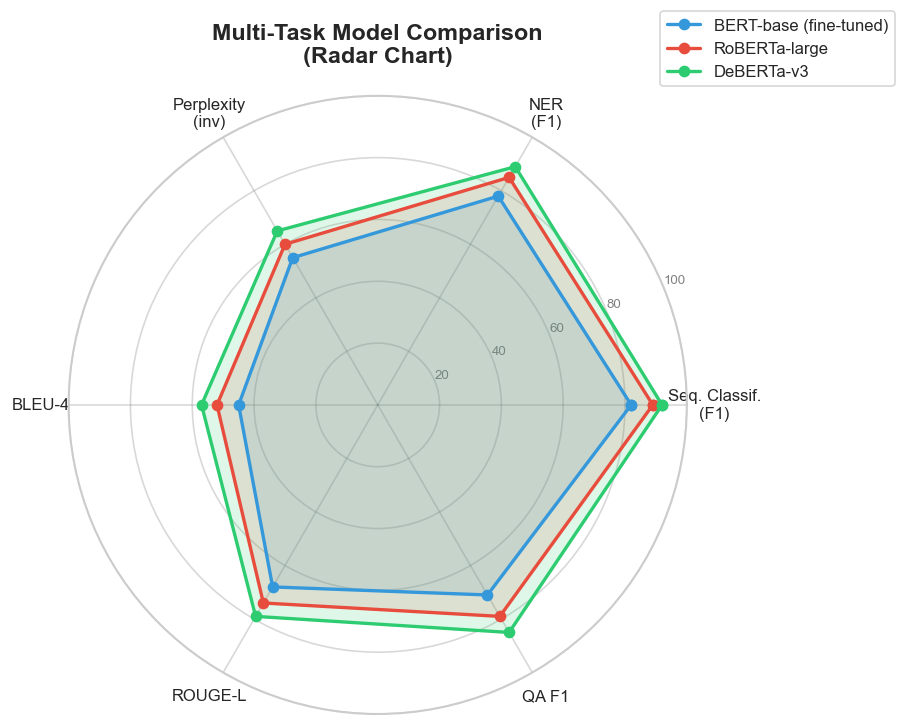

In [16]:
# Simulasi skor 3 model di 6 dimensi evaluasi
dimensions = ['Seq. Classif.\n(F1)', 'NER\n(F1)', 'Perplexity\n(inv)', 'BLEU-4', 'ROUGE-L', 'QA F1']

# Skor 0-100 (perplexity diinvert: higher = better)
model_scores = {
    'BERT-base (fine-tuned)' : [82, 78, 55, 45, 68, 71],
    'RoBERTa-large'           : [89, 85, 60, 52, 74, 79],
    'DeBERTa-v3'              : [92, 89, 65, 57, 79, 85],
}

N_DIM = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N_DIM, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (model_name, scores), color in zip(model_scores.items(), PALETTE):
    values = scores + scores[:1]  # close
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8, color='gray')
ax.grid(color='gray', alpha=0.3)
ax.set_title('Multi-Task Model Comparison\n(Radar Chart)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.show()

### 17. Ringkasan: Tabel Metrik per Task & Panduan
Tabel komprehensif semua metrik evaluasi yang perlu dilaporkan untuk setiap Transformer task.

In [17]:
# === Tabel ringkasan hasil semua task (data dari cell-cell sebelumnya) ===
summary_data = {
    'Task'                    : ['Sequence Classification', 'Token Classification (NER)',
                                  'CausalLM (Text Gen)', 'Machine Translation',
                                  'Summarization', 'Question Answering'],
    'HuggingFace Model'       : ['AutoModelForSequenceClassification',
                                  'AutoModelForTokenClassification',
                                  'AutoModelForCausalLM',
                                  'AutoModelForSeq2SeqLM',
                                  'AutoModelForSeq2SeqLM',
                                  'AutoModelForQuestionAnswering'],
    'Metrik Utama'            : ['Accuracy, F1-Macro, ROC-AUC',
                                  'Entity F1 (seqeval)',
                                  'Perplexity, Loss',
                                  'BLEU-4, chrF',
                                  'ROUGE-1/2/L',
                                  'Exact Match, Token F1'],
    'Skor Contoh (Dummy)'     : [f'Acc={acc:.2f}, F1={f1_mac:.2f}',
                                  f'F1≈{np.mean([s["f1"] for s in ner_stats.values()]):.2f}',
                                  f'PPL={best_ppl:.1f}',
                                  f'BLEU-4={df_bleu["bleu4"].mean():.1f}',
                                  f'ROUGE-L={df_rouge_summary["ROUGE-L"].mean():.1f}',
                                  f'EM={avg_em:.0f}%, F1={avg_f1:.1f}%'],
    'Library Evaluasi'        : ['sklearn.metrics',
                                  'seqeval',
                                  'math.exp(loss)',
                                  'nltk.translate.bleu_score',
                                  'rouge_score',
                                  'Custom EM/F1'],
}

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("  RINGKASAN: METRIK EVALUASI TRANSFORMER TASKS")
print("=" * 80)
display(df_summary.style.set_properties(**{'text-align': 'left'}))

# === Panduan cepat ===
guide = """
╔══════════════════════════════════════════════════════════════════════════╗
║  PANDUAN CEPAT: METRIK MANA YANG HARUS DILAPORKAN?                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║  • SELALU laporkan F1 (bukan hanya Accuracy) untuk imbalanced data      ║
║  • Gunakan seqeval untuk NER (bukan sklearn) — evaluasi di level entitas ║
║  • Perplexity hanya valid dibandingkan model dengan vocab yang SAMA      ║
║  • BLEU bisa menyesatkan untuk kalimat pendek — gunakan smoothing        ║
║  • ROUGE-L lebih informatif dari ROUGE-1 untuk summarization             ║
║  • QA: laporkan KEDUANYA EM dan Token F1 (EM terlalu strict sendiri)    ║
║  • Gunakan Stratified K-Fold untuk dataset kecil                        ║
║  • Selalu visualisasikan Confusion Matrix untuk task klasifikasi         ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(guide)

  RINGKASAN: METRIK EVALUASI TRANSFORMER TASKS


,Task,HuggingFace Model,Metrik Utama,Skor Contoh (Dummy),Library Evaluasi
0,Sequence Classification,AutoModelForSequenceClassification,"Accuracy, F1-Macro, ROC-AUC","Acc=0.84, F1=0.83",sklearn.metrics
1,Token Classification (NER),AutoModelForTokenClassification,Entity F1 (seqeval),F1≈0.91,seqeval
2,CausalLM (Text Gen),AutoModelForCausalLM,"Perplexity, Loss",PPL=3.3,math.exp(loss)
3,Machine Translation,AutoModelForSeq2SeqLM,"BLEU-4, chrF",BLEU-4=32.6,nltk.translate.bleu_score
4,Summarization,AutoModelForSeq2SeqLM,ROUGE-1/2/L,ROUGE-L=59.7,rouge_score
5,Question Answering,AutoModelForQuestionAnswering,"Exact Match, Token F1","EM=30%, F1=70.0%",Custom EM/F1



╔══════════════════════════════════════════════════════════════════════════╗
║  PANDUAN CEPAT: METRIK MANA YANG HARUS DILAPORKAN?                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║  • SELALU laporkan F1 (bukan hanya Accuracy) untuk imbalanced data      ║
║  • Gunakan seqeval untuk NER (bukan sklearn) — evaluasi di level entitas ║
║  • Perplexity hanya valid dibandingkan model dengan vocab yang SAMA      ║
║  • BLEU bisa menyesatkan untuk kalimat pendek — gunakan smoothing        ║
║  • ROUGE-L lebih informatif dari ROUGE-1 untuk summarization             ║
║  • QA: laporkan KEDUANYA EM dan Token F1 (EM terlalu strict sendiri)    ║
║  • Gunakan Stratified K-Fold untuk dataset kecil                        ║
║  • Selalu visualisasikan Confusion Matrix untuk task klasifikasi         ║
╚══════════════════════════════════════════════════════════════════════════╝

